In [10]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import io
from hta.trace_analysis import TraceAnalysis

In [40]:
dfs = []

for d in [f for f in os.scandir("/proj/threadtune-PG0/amir/kineto_traces/") if f.is_dir()]:
    analyzer = TraceAnalysis({0: "device.0.json"}, d.path)
    trace_data = analyzer.t.get_trace(0)
    sym = analyzer.t.symbol_table.get_sym_table()

    df = (
        pl.from_pandas(trace_data[["index", "ts", "dur", "cat", "name"]])
        .with_columns(
            pl.col(col).map_elements(lambda x: sym[x]) for col in ["cat", "name"]
        )
    )
    
    kernel_df = df.filter(pl.col("cat") == "kernel")
    cpu_df = df.filter(pl.col("cat") == "cpu_op")

    cpu_roots_df = cpu_df.join(
        cpu_df.join(cpu_df, how="cross")
        .filter(
            (pl.col("ts") > pl.col("ts_right")) &
            (pl.col("ts") + pl.col("dur") < pl.col("ts_right") + pl.col("dur_right"))
        ),
        on="index",
        how="anti"
    )

    summary_df = pl.DataFrame({
        "benchmark": d.name,
        "kernel_time_sum": kernel_df["dur"].sum(),
        "cpu_operation_time_sum": cpu_roots_df["dur"].sum() - df.filter(pl.col("cat") == "cuda_runtime")["dur"].sum()
    })
    
    dfs.append(summary_df)

final_df = pl.concat(dfs)
final_df

Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json time = 0.10 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425


Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json backend=ParserBackend.JSON in 0.30 seconds; current PID:235119
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json in 0.35 seconds; current PID:235119
leaving parse_multiple_ranks duration=0.36 seconds
leaving parse_traces duration=0.36 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json time = 0.03 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json backend=ParserBackend.JSON in 0.10 seconds; current PID:235119
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json in 0.13 seconds; current PID:235119
leaving parse_multiple_ranks duration

benchmark,kernel_time_sum,cpu_operation_time_sum
str,f64,f64
"""deit-train""",11422.0,299394.0
"""gpt2-inference""",2785.0,65457.0
"""bloom-train""",30633.0,42285.0
"""resnet50-train""",10811.0,275098.0
"""gpt2-train""",22942.0,176918.0
…,…,…
"""bert-inference""",1601.0,45293.0
"""deit-inference""",2902.0,121121.0
"""bloom-inference""",4497.0,58469.0


In [41]:
old_df = pl.read_csv("../prev_data.csv")
final_df = final_df.join(
    old_df,
    on="benchmark"
)

In [42]:
final_df.columns

['benchmark',
 'kernel_time_sum',
 'cpu_operation_time_sum',
 'accel_power_W',
 'accel_time_us',
 'measured_power_W',
 'measured_time_us',
 'idle_power_W',
 'idle_time_us']

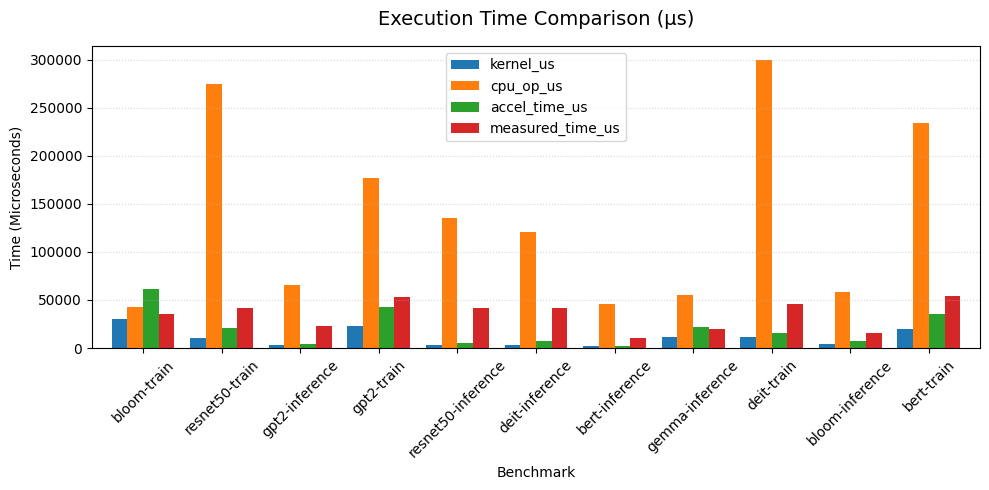

In [44]:
plot_df = final_df.select([
    "benchmark",
    (pl.col("kernel_time_sum")).alias("kernel_us"),
    (pl.col("cpu_operation_time_sum")).alias("cpu_op_us"),
    pl.col("accel_time_us"),
    pl.col("measured_time_us")
]).to_pandas().set_index("benchmark")

ax = plot_df.plot(kind="bar", figsize=(10, 5), width=0.8, logy=False)

plt.title("Execution Time Comparison (μs)", fontsize=14, pad=15)
plt.ylabel("Time (Microseconds)")
plt.xlabel("Benchmark")
plt.xticks(rotation=45)
plt.legend(frameon=True, loc='best')
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()